# 🩺 Clinical Diabetes Risk Prediction & Data Curation Pipeline
**Course Project:** 45-Day Data Curation & Machine Learning with Python  
**Author:** Tanbir S  
**Domain:** Healthcare Analytics / Clinical Endocrinology  
**Dataset:** National Institute of Diabetes and Digestive and Kidney Diseases (Pima Indians Cohort)

---

## 📌 1. Project Objectives & Problem Statement
1. **Data Curation & Quality Auditing:** Identify and resolve missing data encoded as biological impossibilities (e.g. zero glucose, zero blood pressure).
2. **Exploratory Data Analysis (EDA):** Analyze distributions, class imbalances, and correlations using Pandas, NumPy, Matplotlib, and Seaborn.
3. **Clinical Feature Engineering:** Construct composite metabolic risk scores and interaction indicators.
4. **Machine Learning Modeling:** Build, cross-validate, and benchmark multiple classification algorithms (Logistic Regression, Random Forest, Gradient Boosting, and Soft-Voting Ensemble).
5. **Model Evaluation & Clinical Diagnostics:** Assess performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
6. **Artifact Export:** Save the full production-ready scikit-learn pipeline for web deployment.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import joblib

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette('deep')
%matplotlib inline

## 📥 2. Data Ingestion & Initial Inspection

In [2]:
# Load raw dataset
df_raw = pd.read_csv("data/diabetes_raw.csv")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df_raw.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 🛠️ 3. Data Curation: Handling Biological Zeroes
In human physiology, values of `0` for **Glucose**, **Blood Pressure**, **Skin Thickness**, **Insulin**, and **BMI** are medically impossible. They indicate missing or unrecorded test results.

We convert these zero values to `NaN` and examine missingness rates.

In [5]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_curated = df_raw.copy()

print("Biological Zero Frequencies:")
for col in zero_cols:
    zero_count = (df_raw[col] == 0).sum()
    pct = zero_count / len(df_raw) * 100
    print(f" - {col:15s}: {zero_count} zeros ({pct:.1f}%)")
    df_curated[col] = df_curated[col].replace(0, np.nan)

print("\nMissing values after converting biological zeroes to NaN:")
print(df_curated.isnull().sum())

Biological Zero Frequencies:
 - Glucose        : 5 zeros (0.7%)
 - BloodPressure  : 35 zeros (4.6%)
 - SkinThickness  : 227 zeros (29.6%)
 - Insulin        : 374 zeros (48.7%)
 - BMI            : 11 zeros (1.4%)

Missing values after converting biological zeroes to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### Multivariate K-Nearest Neighbors (KNN) Imputation
Rather than crude mean/median imputation which distorts relationships between clinical features, we apply **KNN Imputation** ($k=5$).

In [6]:
feature_cols = [c for c in df_curated.columns if c != "Outcome"]
knn_imputer = KNNImputer(n_neighbors=5)
df_curated[feature_cols] = knn_imputer.fit_transform(df_curated[feature_cols])

print("Missing values after KNN imputation:")
print(df_curated.isnull().sum())

Missing values after KNN imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 📊 4. Exploratory Data Analysis (EDA)

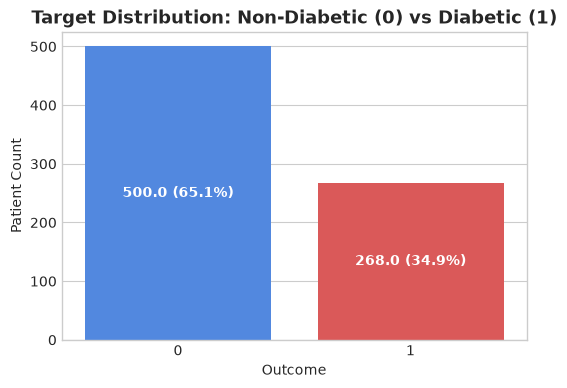

In [7]:
# 1. Target Class Balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_curated, x='Outcome', palette=['#3b82f6', '#ef4444'])
plt.title('Target Distribution: Non-Diabetic (0) vs Diabetic (1)', fontsize=13, fontweight='bold')
plt.xlabel('Outcome')
plt.ylabel('Patient Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(df_curated)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.show()

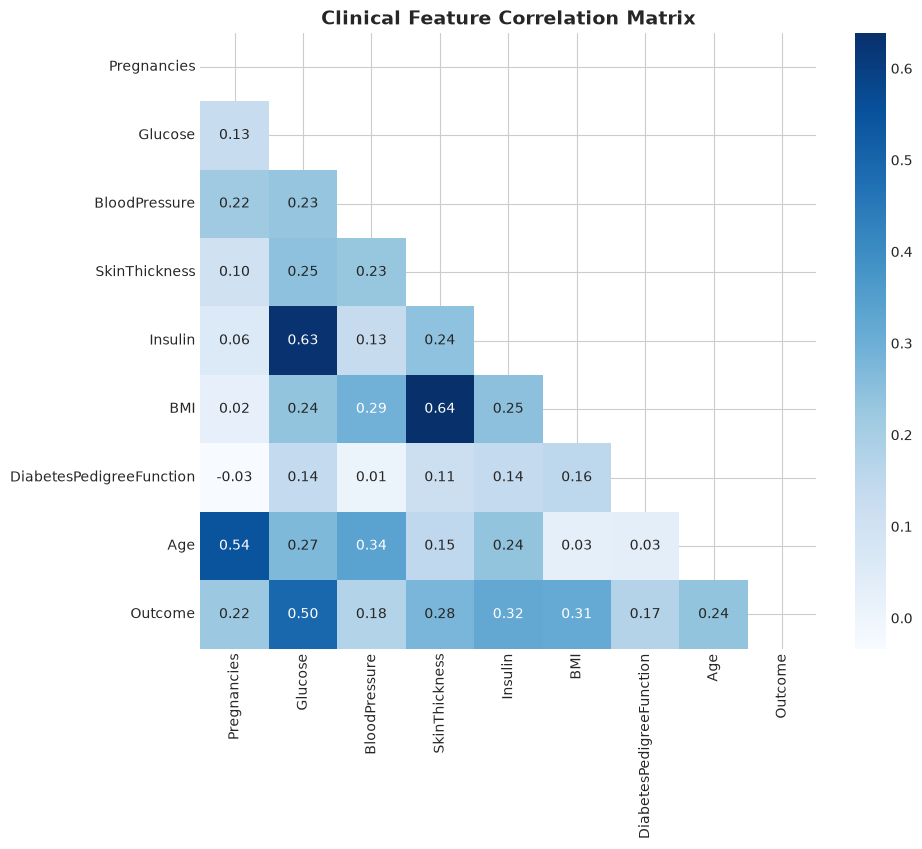

In [8]:
# 2. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
corr = df_curated.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="Blues", cbar=True, square=True)
plt.title("Clinical Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()

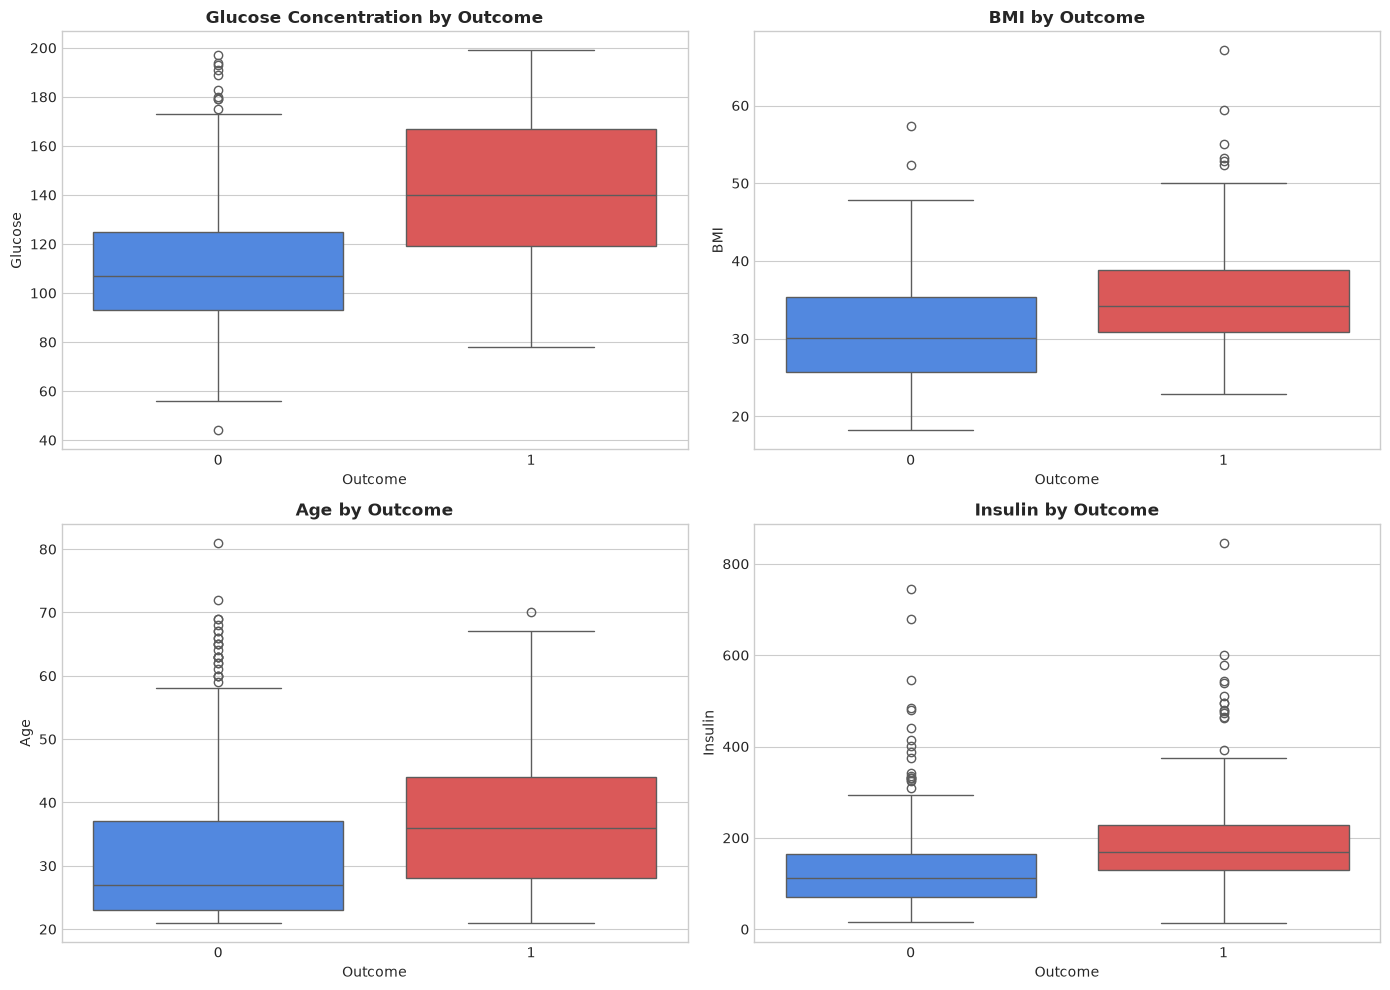

In [9]:
# 3. Distribution of Key Biomarkers by Diabetic Outcome
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(ax=axes[0, 0], data=df_curated, x='Outcome', y='Glucose', palette=['#3b82f6', '#ef4444'])
axes[0, 0].set_title('Glucose Concentration by Outcome', fontweight='bold')

sns.boxplot(ax=axes[0, 1], data=df_curated, x='Outcome', y='BMI', palette=['#3b82f6', '#ef4444'])
axes[0, 1].set_title('BMI by Outcome', fontweight='bold')

sns.boxplot(ax=axes[1, 0], data=df_curated, x='Outcome', y='Age', palette=['#3b82f6', '#ef4444'])
axes[1, 0].set_title('Age by Outcome', fontweight='bold')

sns.boxplot(ax=axes[1, 1], data=df_curated, x='Outcome', y='Insulin', palette=['#3b82f6', '#ef4444'])
axes[1, 1].set_title('Insulin by Outcome', fontweight='bold')

plt.tight_layout()
plt.show()

## 🧬 5. Clinical Feature Engineering
We engineer domain-driven interaction features:
1. `BMI_Age_Risk`: $\text{BMI} \times \text{Age} / 100$
2. `Glucose_BMI_Risk`: $\text{Glucose} \times \text{BMI} / 100$
3. `Insulin_Glucose_Ratio`: $\text{Insulin} / \text{Glucose}$ (Insulin resistance proxy)

In [10]:
from model_utils import BiologicalZeroImputer, MedicalFeatureEngineering

# Demonstrate feature engineering
fe = MedicalFeatureEngineering()
engineered_data = fe.transform(df_curated.drop("Outcome", axis=1))
engineered_cols = feature_cols + ["BMI_Age_Risk", "Glucose_BMI_Risk", "Insulin_Glucose_Ratio"]
df_engineered = pd.DataFrame(engineered_data, columns=engineered_cols)
df_engineered.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,BMI_Age_Risk,Glucose_BMI_Risk,Insulin_Glucose_Ratio
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,16.800,49.728,1.141892
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,8.246,22.610,0.689412
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,7.456,42.639,0.899454
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,5.901,25.009,1.056180
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,14.223,59.047,1.226277


## 🤖 6. Model Training & Cross-Validation Benchmarking

In [11]:
X = df_raw.drop("Outcome", axis=1)
y = df_raw["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(C=0.6, max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=180, max_depth=6, min_samples_leaf=2, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=120, learning_rate=0.06, max_depth=3, subsample=0.85, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    pipe = Pipeline([
        ("zero_imputer", BiologicalZeroImputer()),
        ("feature_engineer", MedicalFeatureEngineering()),
        ("scaler", RobustScaler()),
        ("classifier", clf)
    ])
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "CV ROC-AUC Mean": round(cv_scores.mean(), 4),
        "CV ROC-AUC Std": round(cv_scores.std(), 4)
    }

# Build Soft Voting Ensemble
ensemble_clf = VotingClassifier(
    estimators=[
        ("gb", models["Gradient Boosting"]),
        ("rf", models["Random Forest"]),
        ("lr", models["Logistic Regression"])
    ],
    voting="soft",
    weights=[3, 2, 1]
)

full_prod_pipeline = Pipeline([
    ("zero_imputer", BiologicalZeroImputer()),
    ("feature_engineer", MedicalFeatureEngineering()),
    ("scaler", RobustScaler()),
    ("classifier", ensemble_clf)
])

cv_ens = cross_val_score(full_prod_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
full_prod_pipeline.fit(X_train, y_train)

y_pred_prod = full_prod_pipeline.predict(X_test)
y_prob_prod = full_prod_pipeline.predict_proba(X_test)[:, 1]

results["Ensemble (Production)"] = {
    "Accuracy": round(accuracy_score(y_test, y_pred_prod), 4),
    "Precision": round(precision_score(y_test, y_pred_prod), 4),
    "Recall": round(recall_score(y_test, y_pred_prod), 4),
    "F1 Score": round(f1_score(y_test, y_pred_prod), 4),
    "ROC-AUC": round(roc_auc_score(y_test, y_prob_prod), 4),
    "CV ROC-AUC Mean": round(cv_ens.mean(), 4),
    "CV ROC-AUC Std": round(cv_ens.std(), 4)
}

df_results = pd.DataFrame(results).T
df_results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV ROC-AUC Mean,CV ROC-AUC Std
Logistic Regression,0.7013,0.5833,0.5185,0.5490,0.8159,0.8420,0.0170
Random Forest,0.6883,0.5652,0.4815,0.5200,0.8080,0.8289,0.0238
Gradient Boosting,0.7403,0.6400,0.5926,0.6154,0.8235,0.8167,0.0291
Ensemble (Production),0.7273,0.6250,0.5556,0.5882,0.8209,0.8294,0.0245


## 📈 7. Evaluation & Diagnostic Charts

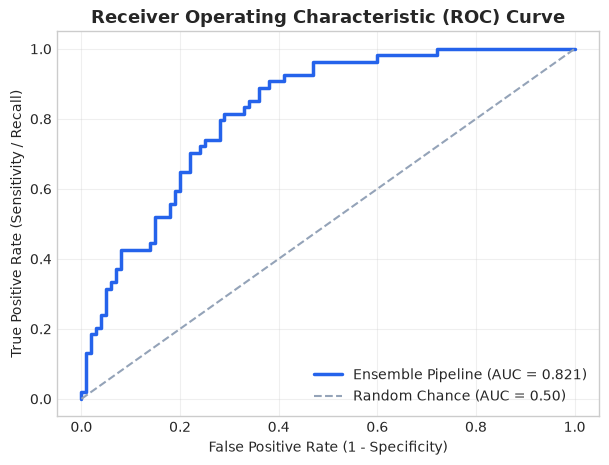

In [12]:
# 1. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_prod)
auc_val = roc_auc_score(y_test, y_prob_prod)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2563eb', lw=2.5, label=f'Ensemble Pipeline (AUC = {auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='#94a3b8', linestyle='--', label='Random Chance (AUC = 0.50)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

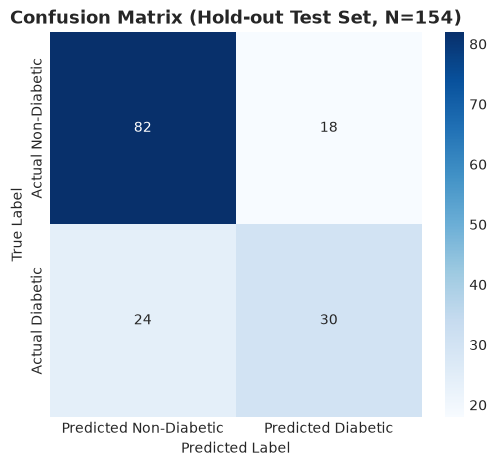

In [13]:
# 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_prod)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Diabetic', 'Predicted Diabetic'],
            yticklabels=['Actual Non-Diabetic', 'Actual Diabetic'])
plt.title('Confusion Matrix (Hold-out Test Set, N=154)', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [14]:
# Classification Report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_prod, target_names=["Non-Diabetic", "Diabetic"]))

Detailed Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.82      0.80       100
    Diabetic       0.62      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



## 💾 8. Model Artifact Persistence
The full pipeline object is exported to `.joblib` for consumption by the interactive Streamlit Web App.

In [15]:
# Verify saved pipeline
saved_artifact = joblib.load("models/diabetes_pipeline.joblib")
print("Model Pipeline successfully verified on disk!")
print("Pipeline steps:", saved_artifact["model_pipeline"].named_steps.keys())

Model Pipeline successfully verified on disk!
Pipeline steps: dict_keys(['zero_imputer', 'feature_engineer', 'scaler', 'classifier'])
